# 01 · Análise Exploratória (EDA)

Este é o primeiro notebook de um projeto de credit scoring com otimização de ponto de corte e interpretabilidade.

O cenário: uma cooperativa quer automatizar a concessão de crédito, perdendo menos com inadimplência, mas sem recusar tanto bom pagador a ponto de travar a carteira.

Os dados vêm da competição [Give Me Some Credit (Kaggle)](https://www.kaggle.com/c/GiveMeSomeCredit): 150 mil tomadores, e o alvo `SeriousDlqin2yrs` indica se a pessoa teve um atraso de 90 dias ou mais nos dois anos seguintes.

Antes de pensar em modelo, quero entender bem a base: o que falta, o que está errado, o que parece código de sistema disfarçado de número e quais variáveis já mostram relação clara com o default. Tudo o que for descoberto aqui vira uma regra de tratamento no próximo notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Paleta: azul = adimplente / geral, laranja = inadimplente
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#52514e"
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#d0cfca", "grid.color": "#ecebe7", "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.labelcolor": GRAY, "xtick.color": GRAY, "ytick.color": GRAY,
    "figure.dpi": 110, "savefig.bbox": "tight",
})
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", 50)

def savefig(fig, name):
    fig.savefig(FIG / f"eda_{name}.png", dpi=150)

## 1. Carga e visão geral

In [2]:
train_raw = pd.read_csv(RAW / "cs-training.csv", index_col=0)
test_raw = pd.read_csv(RAW / "cs-test.csv", index_col=0)

print(f"Treino: {train_raw.shape}  |  Teste: {test_raw.shape}")
print(f"Alvo no teste preenchido? {test_raw['SeriousDlqin2yrs'].notna().any()}")
train_raw.head()

Treino: (150000, 11)  |  Teste: (101503, 11)
Alvo no teste preenchido? False


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766,45,2,0.803,"9,120.000",13,0,6,0,2.000
2,0,0.957,40,0,0.122,"2,600.000",4,0,0,0,1.000
3,0,0.658,38,1,0.085,"3,042.000",2,1,0,0,0.000
4,0,0.234,30,0,0.036,"3,300.000",5,0,0,0,0.000
5,0,0.907,49,1,0.025,"63,588.000",7,0,1,0,0.000


O `cs-test.csv` do Kaggle veio sem o alvo, porque era o arquivo de submissão da competição. Ele não serve para medir desempenho, então vou trabalhar só com o `cs-training.csv` e fazer minha própria divisão em treino, validação e teste, mantendo a proporção de inadimplentes. O arquivo de teste ainda pode ser útil no fim, como uma "base de produção" para simular o escoramento de propostas novas.

Os nomes originais das colunas são longos demais, então renomeio tudo para `snake_case` e deixo um dicionário de dados abaixo.

In [3]:
RENAME = {
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_util",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines",
    "NumberOfTimes90DaysLate": "late_90",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89",
    "NumberOfDependents": "dependents",
}
DESCRIPTION = {
    "default": "Atraso de 90+ dias nos 2 anos seguintes (alvo)",
    "revolving_util": "Utilização do limite rotativo sem garantia (saldo / limite)",
    "age": "Idade do tomador (anos)",
    "late_30_59": "Nº de vezes com atraso de 30–59 dias (últimos 2 anos)",
    "debt_ratio": "Pagamentos mensais de dívida / renda mensal",
    "monthly_income": "Renda mensal",
    "open_credit_lines": "Nº de empréstimos e linhas de crédito abertas",
    "late_90": "Nº de vezes com atraso de 90+ dias",
    "real_estate_loans": "Nº de financiamentos imobiliários",
    "late_60_89": "Nº de vezes com atraso de 60–89 dias (últimos 2 anos)",
    "dependents": "Nº de dependentes",
}

df = train_raw.rename(columns=RENAME)
FEATURES = [c for c in df.columns if c != "default"]
LATE_COLS = ["late_30_59", "late_60_89", "late_90"]

pd.DataFrame({
    "original": list(RENAME.keys()),
    "descrição": [DESCRIPTION[v] for v in RENAME.values()],
    "tipo": [str(df[v].dtype) for v in RENAME.values()],
}, index=list(RENAME.values()))

,original,descrição,tipo
default,SeriousDlqin2yrs,Atraso de 90+ dias nos 2 anos seguintes (alvo),int64
revolving_util,RevolvingUtilizationOfUnsecuredLines,Utilização do limite rotativo sem garantia (sa...,float64
age,age,Idade do tomador (anos),int64
late_30_59,NumberOfTime30-59DaysPastDueNotWorse,Nº de vezes com atraso de 30–59 dias (últimos ...,int64
debt_ratio,DebtRatio,Pagamentos mensais de dívida / renda mensal,float64
monthly_income,MonthlyIncome,Renda mensal,float64
open_credit_lines,NumberOfOpenCreditLinesAndLoans,Nº de empréstimos e linhas de crédito abertas,int64
late_90,NumberOfTimes90DaysLate,Nº de vezes com atraso de 90+ dias,int64
real_estate_loans,NumberRealEstateLoansOrLines,Nº de financiamentos imobiliários,int64
late_60_89,NumberOfTime60-89DaysPastDueNotWorse,Nº de vezes com atraso de 60–89 dias (últimos ...,int64


## 2. Variável alvo — desbalanceamento

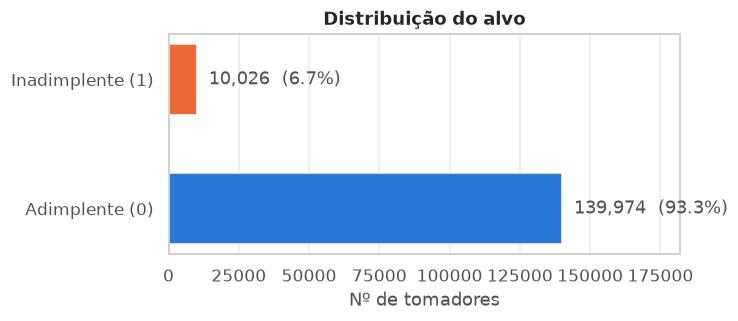

Taxa de default: 6.68%  →  ~1 inadimplente para cada 14 adimplentes


In [4]:
default_rate = df["default"].mean()
counts = df["default"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.barh(["Adimplente (0)", "Inadimplente (1)"], counts.values, color=[BLUE, ORANGE], height=0.55)
for i, v in enumerate(counts.values):
    ax.text(v, i, f"  {v:,}  ({v / len(df):.1%})", va="center", color=GRAY)
ax.set_xlim(0, counts.max() * 1.3)
ax.set_title("Distribuição do alvo")
ax.set_xlabel("Nº de tomadores")
ax.grid(axis="y", visible=False)
savefig(fig, "target")
plt.show()

print(f"Taxa de default: {default_rate:.2%}  →  ~1 inadimplente para cada {1 / default_rate - 1:.0f} adimplentes")

Cerca de 1 em cada 15 tomadores deu default. Com essa proporção, acurácia não diz nada: um modelo que aprova todo mundo acerta uns 93%. Por isso vou avaliar os modelos com ROC-AUC, Gini e KS, que são as métricas usadas no mercado de crédito, e todas as divisões da base serão estratificadas pelo alvo.

Também não vou usar SMOTE ou outro oversampling. A simulação financeira do ponto de corte depende de probabilidades que façam sentido como probabilidade, e reamostrar a base distorce isso. Se o desbalanceamento atrapalhar o treino, uso `class_weight` / `scale_pos_weight` e confiro a calibração depois.

## 3. Qualidade dos dados

### 3.1 Valores faltantes e duplicados

In [5]:
missing = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "%_faltantes": df.isna().mean() * 100,
}).query("n_faltantes > 0")
display(missing)

n_dup = df.duplicated().sum()
both = df["monthly_income"].isna() & df["dependents"].isna()
print(f"Dependentes faltantes que também não têm renda: {both.sum() / df['dependents'].isna().sum():.0%}")
print(f"Linhas duplicadas (todas as colunas iguais): {n_dup:,} ({n_dup / len(df):.2%})")

,n_faltantes,%_faltantes
monthly_income,29731,19.821
dependents,3924,2.616


Dependentes faltantes que também não têm renda: 100%
Linhas duplicadas (todas as colunas iguais): 609 (0.41%)


Os duplicados provavelmente são pessoas diferentes com o mesmo perfil. A base tem poucas variáveis, quase todas contagens, então é fácil dois jovens sem renda informada, sem dívida e sem atraso terem exatamente a mesma linha. Como não existe ID de cliente para confirmar, prefiro mantê-los: apagar mudaria a distribuição real.

### 3.2 Quem não informa a renda é diferente?

In [6]:
income_na = df["monthly_income"].isna()
display(
    df.groupby(income_na.rename("renda_faltante"))
      .agg(n=("default", "size"), taxa_default=("default", "mean"),
           debt_ratio_mediana=("debt_ratio", "median"))
)

,n,taxa_default,debt_ratio_mediana
renda_faltante,,,
False,120269,0.069,0.296
True,29731,0.056,"1,159.000"


Aqui aparece uma coisa importante. Quando a renda está faltando, a mediana do `debt_ratio` passa de mil, o que não faz sentido para uma razão dívida/renda. O mais provável é que, sem renda, o sistema tenha gravado o valor da dívida no lugar da razão (como se dividisse por 1).

E quem não informou renda inadimple menos do que quem informou, então o faltante não é aleatório e carrega informação. Quase todo mundo que não informou dependentes também não informou renda, o que sugere um mesmo grupo de cadastros incompletos.

Na prática isso significa três coisas: criar uma flag `income_missing`, não confiar no `debt_ratio` quando a renda falta (ele vira uma categoria à parte no WoE e um valor especial no LightGBM) e não sair imputando a renda pela média.

### 3.3 Renda zero e o `debt_ratio` de quem informou renda

In [7]:
print(f"Renda = 0: {(df['monthly_income'] == 0).sum():,} tomadores "
      f"(taxa default {df.loc[df['monthly_income'] == 0, 'default'].mean():.2%})")
print(f"Renda <= 1: {(df['monthly_income'] <= 1).sum():,}")

has_income = df["monthly_income"] > 1
print("\ndebt_ratio com renda informada (>1):")
display(df.loc[has_income, "debt_ratio"].describe(percentiles=[.5, .9, .99, .999]).to_frame().T)

Renda = 0: 1,634 tomadores (taxa default 4.04%)
Renda <= 1: 2,239

debt_ratio com renda informada (>1):


,count,mean,std,min,50%,90%,99%,99.9%,max
debt_ratio,"118,030.000",0.417,2.758,0.000,0.291,0.712,2.044,10.785,450.333


### 3.4 Valores impossíveis ou extremos

In [8]:
checks = {
    "age == 0": df["age"] == 0,
    "age < 18": df["age"] < 18,
    "revolving_util > 1": df["revolving_util"] > 1,
    "revolving_util > 10": df["revolving_util"] > 10,
    "late_* >= 96 (código especial)": (df[LATE_COLS] >= 96).any(axis=1),
    "real_estate_loans > 20": df["real_estate_loans"] > 20,
    "dependents > 10": df["dependents"] > 10,
}
pd.DataFrame({
    "n": {k: m.sum() for k, m in checks.items()},
    "taxa_default": {k: df.loc[m, "default"].mean() for k, m in checks.items()},
})

,n,taxa_default
age == 0,1,0.000
age < 18,1,0.000
revolving_util > 1,3321,0.372
revolving_util > 10,241,0.071
late_* >= 96 (código especial),269,0.546
real_estate_loans > 20,10,0.200
dependents > 10,2,0.000


Estourar o limite do rotativo (`revolving_util` acima de 1) é um sinal forte de risco. Mas acima de 10 a taxa de default volta para perto da média, o que indica erro de registro, talvez o saldo gravado sem dividir pelo limite. A relação deixa de ser monotônica na cauda, então esses valores precisam ser limitados (winsorização) no modelo linear ou isolados num bin próprio.

### 3.5 Os códigos 96 e 98 nas variáveis de atraso
As três variáveis de atraso têm valores 96 e 98, e ninguém atrasa 98 vezes em dois anos. Vale olhar a cauda dessas colunas.

In [9]:
tail = pd.concat({c: df[c].value_counts().sort_index() for c in LATE_COLS}, axis=1).fillna(0).astype(int).sort_index()
display(tail.loc[tail.index >= 8].T)

special = (df[LATE_COLS] >= 96)
print("As 3 colunas têm código especial nas MESMAS linhas?",
      (special.all(axis=1) == special.any(axis=1)).all())
print(f"Taxa de default nessas linhas: {df.loc[special.any(axis=1), 'default'].mean():.1%} "
      f"(vs {default_rate:.1%} na base)")

,8,9,10,11,12,13,14,15,17,96,98
late_30_59,25,12,4,1,2,1,0,0,0,5,264
late_60_89,2,1,0,1,0,0,0,0,0,5,264
late_90,21,19,8,5,2,4,2,2,1,5,264


As 3 colunas têm código especial nas MESMAS linhas? True
Taxa de default nessas linhas: 54.6% (vs 6.7% na base)


Existe um salto entre 17 e 96, sem nenhum valor no meio. Então 96 e 98 são códigos de sistema (algo como "desconhecido" ou "recusado"), não contagens. E as linhas marcadas com eles são de risco muito alto.

Vou trocar esses códigos por `NaN` nas colunas de atraso e criar uma flag `late_special_code`. Na regressão logística com WoE eles viram um bin próprio, com WoE alto, e o LightGBM lida com `NaN` nativamente. Deixar 96 e 98 como número distorceria médias, correlações e principalmente o modelo linear.

## 4. Distribuições
As variáveis contínuas têm caudas enormes, então corto os gráficos no percentil 99 para enxergar onde está a maior parte dos dados, separando adimplentes de inadimplentes.

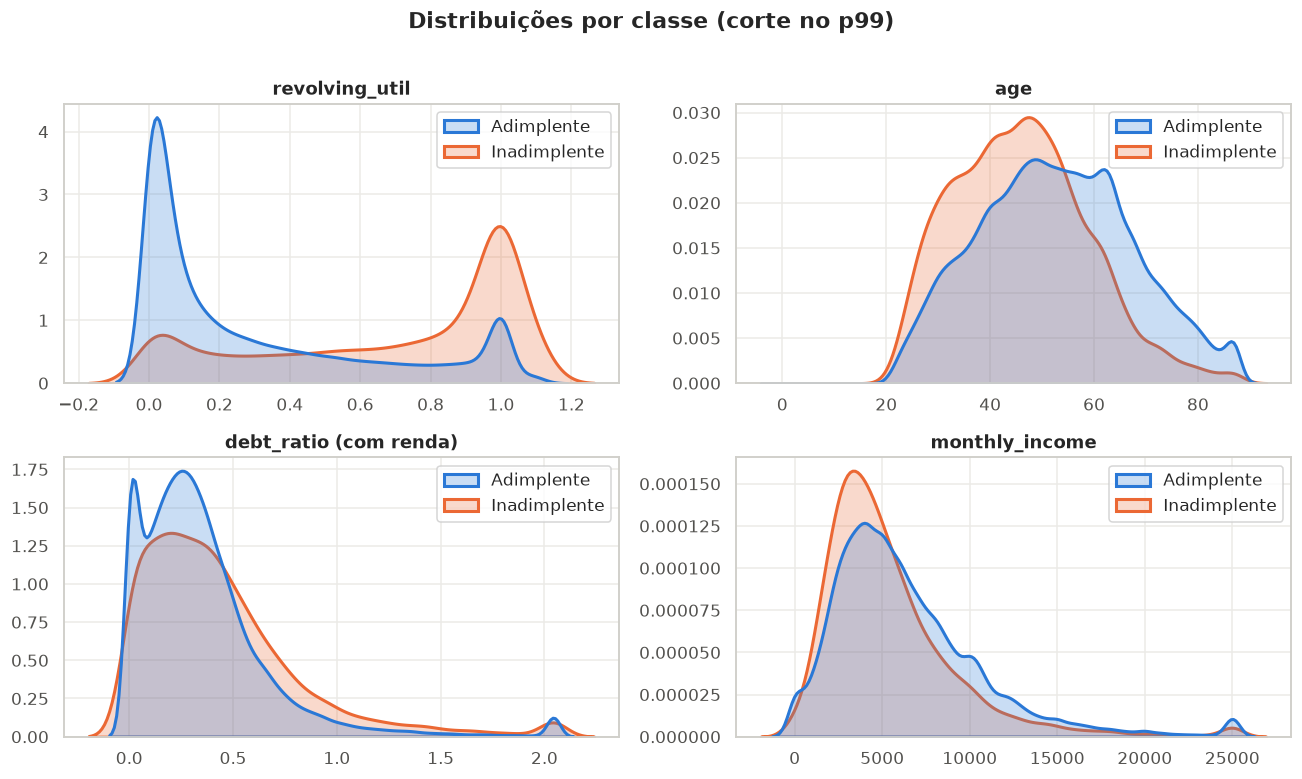

In [10]:
def clip_p99(s: pd.Series) -> pd.Series:
    # Visão só para plot: corta a cauda no percentil 99
    return s.clip(upper=s.quantile(0.99))

CONT = ["revolving_util", "age", "debt_ratio", "monthly_income"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flat, CONT):
    data = df[has_income] if col == "debt_ratio" else df  # debt_ratio só onde a razão faz sentido
    data = data.assign(**{col: clip_p99(data[col])})
    sns.kdeplot(data=data, x=col, hue="default", common_norm=False, fill=True, alpha=0.25,
                palette={0: BLUE, 1: ORANGE}, ax=ax, linewidth=2, warn_singular=False)
    ax.set_title(col + (" (com renda)" if col == "debt_ratio" else ""))
    ax.set_xlabel("")
    ax.set_ylabel("")
    leg = ax.get_legend()
    if leg: leg.set_title(""); [t.set_text(l) for t, l in zip(leg.texts, ["Adimplente", "Inadimplente"])]
fig.suptitle("Distribuições por classe (corte no p99)", fontweight="bold", y=1.01)
fig.tight_layout()
savefig(fig, "distributions")
plt.show()

A diferença mais gritante está no `revolving_util`: os inadimplentes se concentram perto de 1, ou seja, com o limite praticamente todo usado. Deve ser um dos preditores mais fortes. Na idade, os inadimplentes são visivelmente mais jovens. Em `monthly_income` e `debt_ratio` as curvas quase se sobrepõem, então espero um poder de separação menor.

## 5. Taxa de default por faixa
Para cada variável, divido a base em faixas (decis, no caso das contínuas) e calculo a taxa de default em cada uma. É a mesma intuição por trás do WoE: se a taxa sobe ou desce de forma consistente entre as faixas, a variável separa bem bons e maus pagadores e se encaixa bem num modelo linear.

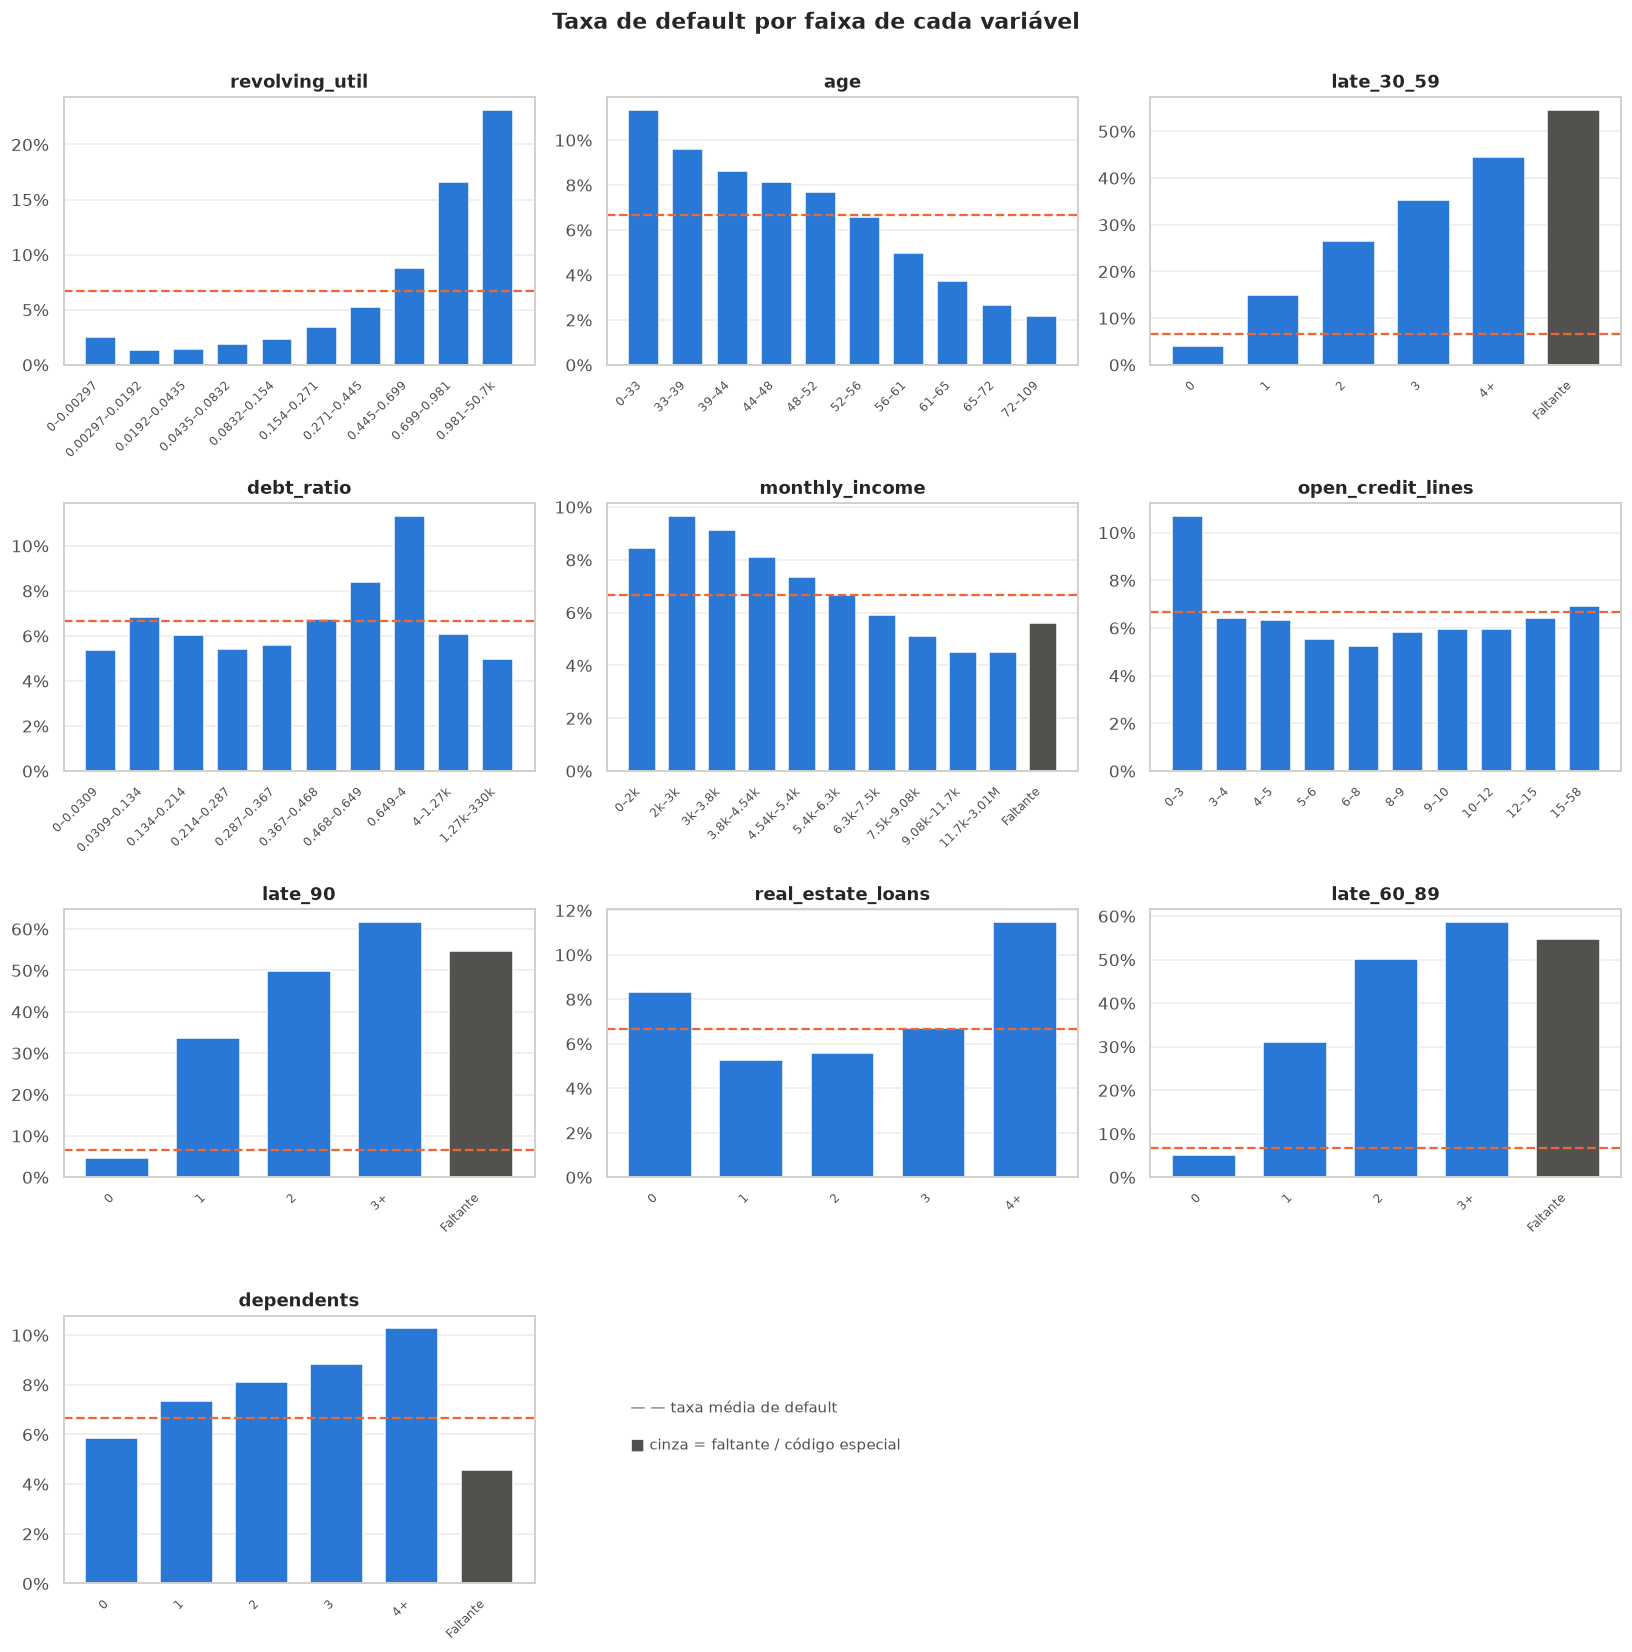

In [11]:
df_clean = df.copy()
df_clean[LATE_COLS] = df_clean[LATE_COLS].where(df_clean[LATE_COLS] < 96)

def fmt_num(x: float) -> str:
    x = max(x, 0)  # qcut estende o limite inferior para -0.001
    if x >= 1e6: return f"{x / 1e6:.3g}M"
    if x >= 1e3: return f"{x / 1e3:.3g}k"
    return f"{x:.3g}"

COUNT_CAP = {"late_30_59": 4, "late_60_89": 3, "late_90": 3, "real_estate_loans": 4, "dependents": 4}

def default_rate_by_bin(s: pd.Series, y: pd.Series, q: int = 10) -> pd.DataFrame:
    # Contagens: valores únicos com teto ("k+"); contínuas: decis
    if s.name in COUNT_CAP:
        cap = COUNT_CAP[s.name]
        codes = s.clip(upper=cap)
        labels = {v: (f"{v:.0f}+" if v == cap else f"{v:.0f}") for v in range(cap + 1)}
    else:
        codes = pd.qcut(s, q=q, duplicates="drop")
        labels = {c: f"{fmt_num(c.left)}–{fmt_num(c.right)}" for c in codes.cat.categories}
        codes = codes.cat.codes.where(s.notna()).astype(float)
        labels = dict(zip(range(len(labels)), labels.values()))
    out = y.groupby(codes.fillna(-1)).agg(n="size", taxa_default="mean")
    out.index = [("Faltante" if i == -1 else labels[i]) for i in out.index]
    # Faltante vai para o final
    return pd.concat([out.drop(index="Faltante", errors="ignore"), out.loc[out.index == "Faltante"]])

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
for ax, col in zip(axes.flat, FEATURES):
    t = default_rate_by_bin(df_clean[col], df_clean["default"])
    colors = [GRAY if i == "Faltante" else BLUE for i in t.index]
    ax.bar(range(len(t)), t["taxa_default"], color=colors, width=0.7)
    ax.axhline(default_rate, color=ORANGE, lw=1.5, ls="--")
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels(t.index, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(col)
    ax.grid(axis="x", visible=False)
for ax in axes.flat[len(FEATURES):]:
    ax.axis("off")
axes.flat[len(FEATURES)].text(0.05, 0.5, "— — taxa média de default\n\n■ cinza = faltante / código especial",
                   color=GRAY, fontsize=10, transform=axes.flat[len(FEATURES)].transAxes)
fig.suptitle("Taxa de default por faixa de cada variável", fontweight="bold", y=1.0)
fig.tight_layout()
savefig(fig, "default_rate_by_bin")
plt.show()

Os atrasos passados são, de longe, o sinal mais forte. Um único atraso já multiplica a taxa de default, e ela continua subindo a cada atraso a mais. O bin cinza ("Faltante") nessas colunas são justamente os códigos 96/98, com risco altíssimo.

`revolving_util` sobe de forma consistente e acelera nos últimos decis. A idade faz o caminho inverso: quanto mais velho, menor o risco, numa descida bem regular. A renda segue a mesma lógica (mais renda, menos risco), com exceção do primeiro decil, onde está quem tem renda perto de zero.

Algumas variáveis têm forma de "U". Em `real_estate_loans`, não ter nenhum financiamento ou ter quatro ou mais é mais arriscado do que ter um ou dois. Em `open_credit_lines`, quem tem até três linhas abertas se destaca, talvez por pouco histórico ou por ter tido crédito negado. `debt_ratio` também não é monotônico e ainda está contaminado pelo problema da renda faltante. Nesses casos, um WoE com faixas bem escolhidas resolve bem para o modelo linear. `dependents` tem efeito pequeno.

## 6. Correlação entre variáveis
Uso Spearman, que trabalha com a ordem dos valores e por isso aguenta melhor outliers e caudas longas.

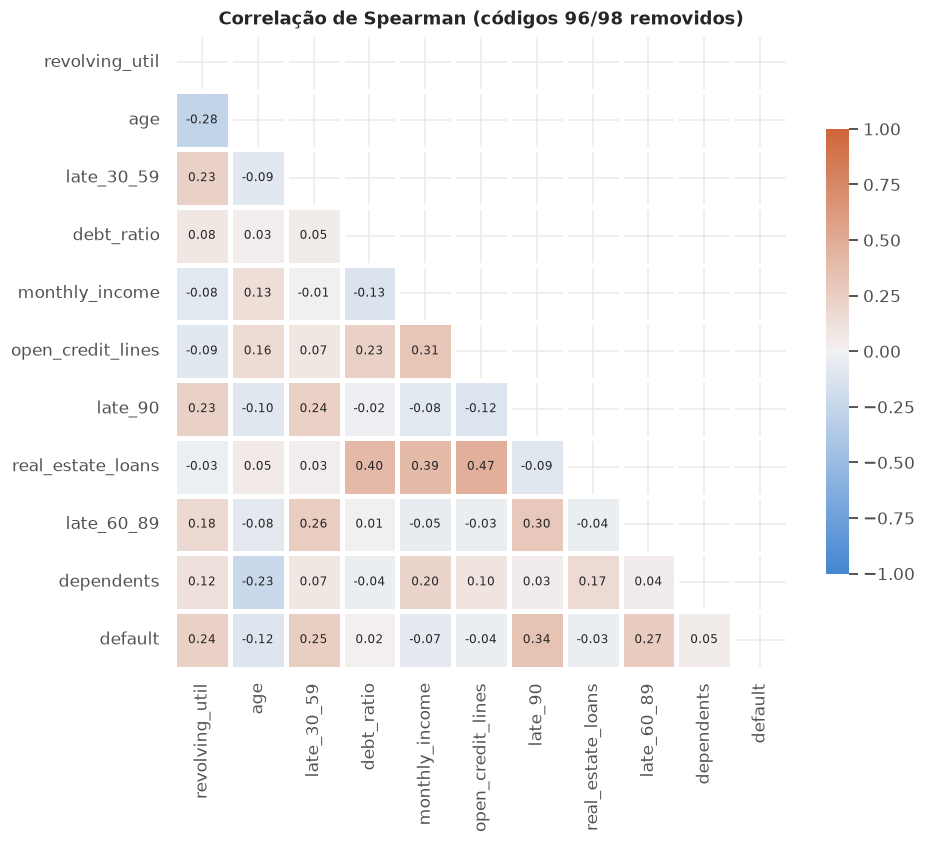

In [12]:
corr = df_clean[FEATURES + ["default"]].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(250, 25, s=80, l=55, as_cmap=True),
            center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=2, linecolor="white", cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlação de Spearman (códigos 96/98 removidos)")
savefig(fig, "correlation")
plt.show()

As três variáveis de atraso são correlacionadas entre si, mas longe de serem redundantes. `open_credit_lines` e `real_estate_loans` andam juntas, o que faz sentido: quem tem mais produtos tem mais linhas abertas.

A célula abaixo mostra por que valeu a pena tratar os códigos 96/98. Com eles, as colunas de atraso parecem quase perfeitamente correlacionadas. Sem eles, a correlação cai bastante. Aquela correlação toda era um artefato dos códigos, não uma relação real.

In [13]:
print("Pearson com códigos 96/98 (bruto):")
display(df[LATE_COLS].corr())
print("Pearson sem códigos 96/98:")
display(df_clean[LATE_COLS].corr())

Pearson com códigos 96/98 (bruto):


,late_30_59,late_60_89,late_90
late_30_59,1.000,0.987,0.984
late_60_89,0.987,1.000,0.993
late_90,0.984,0.993,1.000


Pearson sem códigos 96/98:


,late_30_59,late_60_89,late_90
late_30_59,1.000,0.306,0.218
late_60_89,0.306,1.000,0.295
late_90,0.218,0.295,1.000


## 7. O que levar para a próxima etapa

| # | O que vimos | O que fazer no pré-processamento |
|---|---|---|
| 1 | `cs-test.csv` não tem alvo | Usar só o treino, com divisão estratificada em treino, validação e teste |
| 2 | Alvo desbalanceado | Avaliar com KS, AUC e Gini; sem SMOTE; checar calibração |
| 3 | `monthly_income` falta em ~20% dos casos, e isso não é aleatório | Flag `income_missing`; bin próprio no WoE; `NaN` nativo no LightGBM |
| 4 | `debt_ratio` não faz sentido quando a renda falta | Tratar `debt_ratio` como faltante / bin próprio nesses casos |
| 5 | Códigos 96/98 em `late_*`, sempre nas mesmas linhas e com risco altíssimo | Converter para `NaN` e criar a flag `late_special_code` |
| 6 | `revolving_util` acima de 1 é alto risco, mas acima de 10 volta à média | Winsorizar no modelo linear; os bins do WoE absorvem o resto |
| 7 | Um caso com `age == 0` | Tratar como faltante |
| 8 | Linhas duplicadas | Manter (provavelmente perfis iguais, sem ID para confirmar) |
| 9 | Atrasos, `revolving_util` e idade têm relação forte e monotônica | Devem ter os maiores IVs; confirmar no próximo notebook |

Os números exatos de cada ponto estão nas saídas das células acima.